# Geometric Brownian Motion Demo

Original QMCPy demo: [`QMCPy/demos/GBM/gbm_demo.ipynb`](../../QMCPy/demos/GBM/gbm_demo.ipynb)

Demonstrates GeometricBrownianMotion for financial modeling: S(t) = S₀ exp[(γ - σ²/2) t + σ W(t)]

where W(t) is a standard Brownian motion.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/gbm_demo.ipynb)

Parity note: the QMCPy notebook covers built-in GBM objects, log-normal moment checks, Brownian-motion comparisons, and low-discrepancy sampling, then adds interactive widgets and QuantLib validation. This Julia notebook keeps the directly comparable GBM path, log-normal moment, Brownian-construction, and option-pricing examples, omits the widget and QuantLib sections, and closes with a Julia sampler-comparison summary.


In [1]:
using QMC
using Statistics
using Printf

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## GBM Objects in QMCPy

Geometric Brownian Motion in `QMC.jl` plays the same role as the QMCPy `GeometricBrownianMotion` object. We begin with a compact constructor-and-sampling walkthrough and then check the key log-normal moment property.


In [2]:
println("="^60)
println("GeometricBrownianMotion: Basic Usage")
println("="^60)

d = 4           # 4 time steps
S0 = 100.0      # initial price
γ = 0.05        # drift (5% annual return)
σ2 = 0.04       # diffusion (volatility² = 20% vol)

dd = DigitalNetB2(d; seed=7)
gbm = GeometricBrownianMotion(dd;
    t_final=1.0, initial_value=S0, drift=γ, diffusion=σ2)

println("  $gbm")
println("  Time vector: t = [$(join([@sprintf("%.2f", t) for t in gbm.time_vector], ", "))]")
println()

n = 10_000
x = gen_samples(dd, n)
paths = transform(gbm, x)

println("  Generated $n sample paths")
println("  Path shape: $(size(paths))")
println()

GeometricBrownianMotion: Basic Usage
  GeometricBrownianMotion(d=4, S₀=100.0, γ=0.05, σ²=0.04)


  Time vector: t = [0.25, 0.50, 0.75, 1.00]

  Generated 10000 sample paths


  Path shape: (10000, 4)



Now create a simple GBM instance and generate sample paths to see the class in action.


In [3]:
println("  First 5 paths (S₀, S(t₁), S(t₂), S(t₃), S(T)):")
for i in 1:5
    @printf("    Path %d: %6.2f → [%6.2f  %6.2f  %6.2f  %6.2f]\n",
            i, S0, paths[i,1], paths[i,2], paths[i,3], paths[i,4])
end
println()

  First 5 paths (S₀, S(t₁), S(t₂), S(t₃), S(T)):
    Path 1: 100.00 → [ 85.62   92.05   83.53   77.14]
    Path 2: 100.00 → [ 95.39   94.21  106.62  117.46]


    Path 3: 100.00 → [110.73   95.91   95.74   91.52]
    Path 4: 100.00 → [102.05  113.43  121.68  126.68]
    Path 5: 100.00 → [104.42   94.43   82.58   91.10]



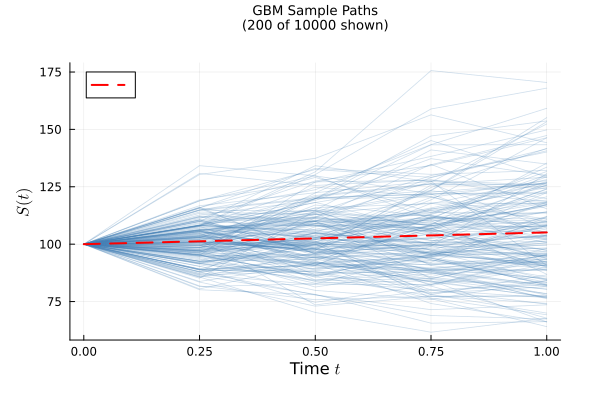

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [4]:
if HAVE_PLOTS
    t_plot = [0.0; gbm.time_vector]
    n_plot = min(200, size(paths, 1))
    S_with_origin = hcat(fill(S0, n_plot), paths[1:n_plot, :])  # n_plot × (d+1)
    p = plot(t_plot, S_with_origin';
        alpha=0.25, color=:steelblue, lw=0.8, label=nothing,
        xlabel="Time \$t\$", ylabel="\$S(t)\$",
        title="GBM Sample Paths\n($(n_plot) of $n shown)")
    # theoretical mean E[S(t)] = S0 exp(γ t)
    E_S = S0 .* exp.(γ .* gbm.time_vector)
    plot!([0.0; gbm.time_vector], [S0; E_S];
        color=:red, lw=2, linestyle=:dash, label="\$E[S(t)] = S_0 \exp(γt)\$")
    display(p)
end


The empirical checks below focus on the same log-normal moment structure highlighted in the QMCPy notebook.


In [5]:
println("="^60)
println("Statistical Properties of GBM")
println("="^60)

Statistical Properties of GBM


### Log-Normality Property


In [6]:
for j in 1:d
    t = gbm.time_vector[j]
    exact_mean = S0 * exp(γ * t)
    empirical_mean = mean(paths[:, j])
    @printf("  t = %.2f: E[S(t)] = %.2f (exact = %.2f, err = %.2f%%)\n",
            t, empirical_mean, exact_mean,
            100.0 * abs(empirical_mean - exact_mean) / exact_mean)
end
println()

  t = 0.25: E[S(t)] = 101.26 (exact = 101.26, err = 0.00%)
  t = 0.50: E[S(t)] = 102.53 (exact = 102.53, err = 0.00%)
  t = 0.75: E[S(t)] = 103.82 (exact = 103.82, err = 0.00%)
  t = 1.00: E[S(t)] = 105.12 (exact = 105.13, err = 0.00%)



GBM values remain strictly positive, unlike Brownian-motion paths.


In [7]:
@printf("  All values positive: %s (min = %.4f)\n",
        all(paths .> 0) ? "YES" : "NO", minimum(paths))
println()

  All values positive: YES (min = 52.1648)



## GMB vs Brownian Motion Comparison

The QMCPy notebook includes a dedicated Brownian-motion versus GBM path-comparison section. The checked-in Julia notebook keeps the same conceptual contrast but expresses it through the option-pricing pipeline below, where `BrownianMotion` and `GeometricBrownianMotion` feed the same `FinancialOption` interface.


# GBM vs Brownian Motion

The next two examples use the same Asian-option problem but differ in whether the path construction starts from `BrownianMotion` or from `GeometricBrownianMotion` directly.


In [8]:
println("="^60)
println("GBM + FinancialOption Integration Pipeline")
println("="^60)

d_opt = 52
dd_opt = IIDStdUniform(d_opt; seed=7)

GBM + FinancialOption Integration Pipeline


IIDStdUniform(d=52)

Using BrownianMotion (internal GBM construction in FinancialOption)


In [9]:
tm_bm = BrownianMotion(dd_opt)
f_bm = FinancialOption(tm_bm;
    option_type=:asian, call_put=:call, mean_type=:arithmetic,
    volatility=0.2, start_price=100.0, strike_price=100.0,
    interest_rate=0.05)
# Slightly relax the demo tolerance so this compact CI-safe example
# converges deterministically without emitting a CubMCCLT warning.
sc_bm = CubMCCLT(f_bm; abs_tol=0.111, n_init=32768)
result_bm = integrate(sc_bm)
@printf("  Asian Call (via BM):  %.4f  (n = %d)\n", result_bm.solution, result_bm.data[:n])

  Asian Call (via BM):  5.8613  (n = 83921)


Using GeometricBrownianMotion directly


In [10]:
dd_opt2 = IIDStdUniform(d_opt; seed=7)
gbm_tm = GeometricBrownianMotion(dd_opt2;
    t_final=1.0, initial_value=100.0, drift=0.05, diffusion=0.04)
f_gbm = FinancialOption(gbm_tm;
    option_type=:asian, call_put=:call, mean_type=:arithmetic,
    volatility=0.2, start_price=100.0, strike_price=100.0,
    interest_rate=0.05)
# Match the BrownianMotion-backed example above so both variants
# converge cleanly in the checked-in notebook run.
sc_gbm = CubMCCLT(f_gbm; abs_tol=0.111, n_init=32768)
result_gbm = integrate(sc_gbm)
@printf("  Asian Call (via GBM): %.4f  (n = %d)\n", result_gbm.solution, result_gbm.data[:n])
println()

@assert isfinite(result_bm.solution) && isfinite(result_gbm.solution)
@assert result_bm.data[:n] > 0 && result_gbm.data[:n] > 0
@assert abs(result_bm.solution - result_gbm.solution) < 0.5


  Asian Call (via GBM): 5.8613  (n = 83921)



Different Volatilities

## GBM Using Low-Discrepancy Lattice Sequence Distrubtion

The final sampler-comparison plot is the Julia analogue of the QMCPy low-discrepancy sampling section. It compares IID, lattice, and digital-net constructions through the terminal-mean error of the same GBM model.


**Julia extension: Sampler Comparison: Terminal Mean Error.**


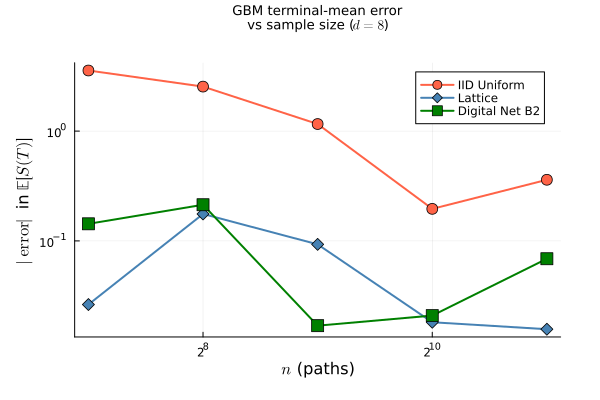

In [11]:
if HAVE_PLOTS
    d_cmp = 8
    ns_cmp = 2 .^ (7:11)
    exact_T = S0 * exp(γ * 1.0)
    function gbm_mae(dd)
        tm = GeometricBrownianMotion(dd; t_final=1.0, initial_value=S0, drift=γ, diffusion=σ2)
        x = transform(tm, gen_samples(dd, ns_cmp[end]))
        [abs(mean(x[1:n, end]) - exact_T) for n in ns_cmp]
    end
    iid_err = gbm_mae(IIDStdUniform(d_cmp; seed=7))
    lat_err = gbm_mae(Lattice(d_cmp; seed=7))
    net_err = gbm_mae(DigitalNetB2(d_cmp; seed=7, graycode=false))

    p = plot(ns_cmp, iid_err;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:tomato, label="IID Uniform",
        xlabel="\$n\$ (paths)", ylabel="\$|\\mathrm{error}|\$ in \$\\mathbb{E}[S(T)]\$",
        title="GBM terminal-mean error\nvs sample size (\$d=$d_cmp\$)")
    plot!(ns_cmp, lat_err; marker=:diamond, lw=2, ms=6, color=:steelblue, label="Lattice")
    plot!(ns_cmp, net_err; marker=:square,  lw=2, ms=6, color=:green, label="Digital Net B2")
    display(p)
end


## Interactive Visualization

The slider-based interactive widget from the QMCPy notebook is not reproduced in the checked-in Julia notebook because it is not a stable fit for headless CI and documentation builds.


## QuantLib vs QMCPy Comparison

The QMCPy notebook validates its GBM implementation against QuantLib. The checked-in Julia demo does not vendor a QuantLib dependency, so that external-library comparison remains out of scope here.


## Acknowledgments

This Julia notebook follows the structure and teaching goals of the corresponding QMCPy demo while keeping the checked-in version lightweight enough for routine reruns.


## References

Glasserman's *Monte Carlo Methods in Financial Engineering* remains the main background reference for the log-normal moment formulas and option-pricing context used in both the QMCPy and QMC.jl demos.


## Appendix: Covariance Matrix Derivation for Geometric Brownian Motion

The full covariance derivation from the QMCPy notebook is not repeated here. The checked-in Julia notebook instead concentrates on the directly executable path, moment, and pricing checks.
